# NASA EPSCoR Progress: Michelson-Morley Loop Characterization
### 20260531 - *Tyndale Stutzman*
---

## Introduction:

The purpose of this notebook is to provide a brief overview of the control theory used to characterize the current feedback system for the initial table-top phase of the Programmable Photonics for Quantum Space Networks project. More details of the optics, electronics, and methods used thus far can be found in [this preliminary notebook](linkhere). <!-- working on turning my doc report into a notebook too -->

## Table of Contents

1. [Step 0: Background](#background)
   1. [System Refresher](#system)
   2. [Control Theory Overview](#theory)
   3. [PID Review](#review)
2. [Step 1: Setup](#setup)
   1. [Environment & Packages](#env)
   2. [PID Configuration](#pid)
   3. [VNA Sweep](#vna)
   4. [Plotting and Analysis](#plot)
3. [Step 2: Save Data](#save)


<a id="background"></a>
## Step 0: Background
<a id="system"></a>
### System Refresher

Before diving into the PID parameters and analysis code, below are graphics of the system architecture and optical schematic which can be helpful in understanding the components at play. 

#### **Figure 1. System Architecture**

In this diagram, the key is to follow the chain of components from ```out1``` and back into ```in1``` on the **Red Pitaya**.

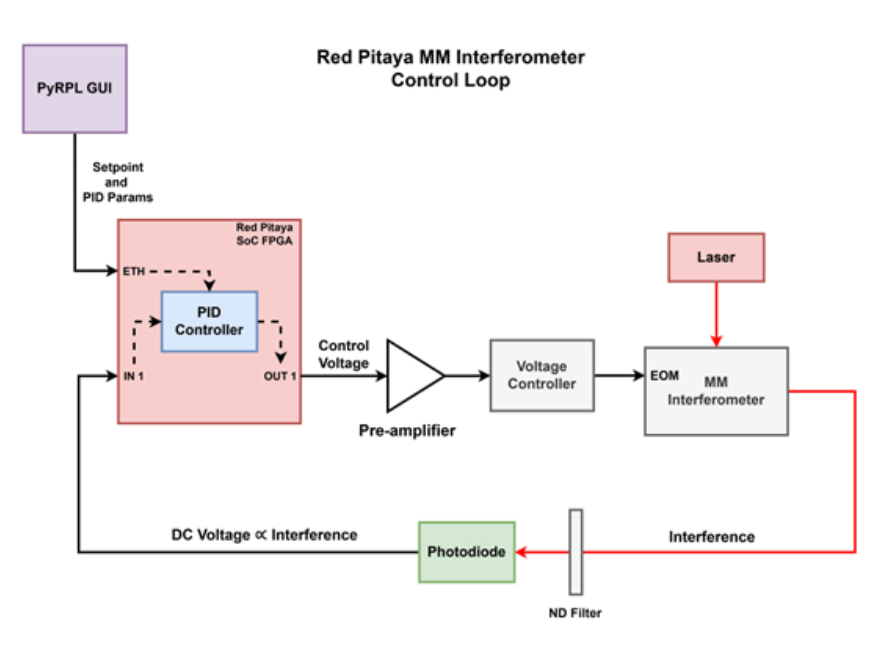


#### **Figure 2. Optical Schematic**

For the optics half of this experiment, the **plant** is isolated as only the **MMI** which is placed after the beam expander **L1**. For this work, optical components before **L1** are not considered to be a part of the system under examination. 

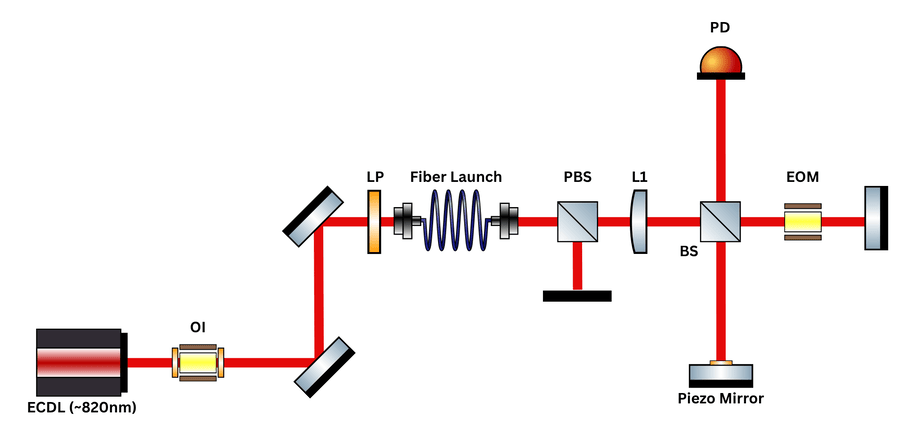


<a id="theory"></a>
### Control Theory Overview

Fundamentally, control theory boils down to stabilization: in a given system with an unstable output, a carefully constructed input $x(t)$ can be designed in order to control the system, and therefore stabilize the output  $y(t)$.

$$x(t) \;\rightarrow\; \text{system} \;\rightarrow\; y(t)$$

Notice, here, we're dealing with real signals, therefore our inputs and outputs are in the time domain. In control theory, it is easiest to work in Laplace space as differentiation simply becomes multiplication and integration becomes division. This will be critical for the construction of our PID control signal as we'll see later. 

To briefly define some of the relevant transfer functions, we'll call the system to be controlled, aka the plant, $G(s)$, and the feedback $H(s)$. For this work, $G(s)$ is a composite transfer function of all of the elements within the broader MMI feedback system, therefore our plant can be considered $G(s) = G_{\mathrm{EOM}}(s)\, G_{\mathrm{Piezo}}(s)\, G_{\mathrm{PD}}(s)\, G_{\mathrm{RP}}(s)$ and so forth. With $G(s)$ and $H(s)$ we can sufficiently measure and construct both the open loop transfer function, ```OLTF```, and the closed loop transfer function, ```CLTF```, in order to characterize the bandwidth of the system as a whole. The ```CLTF``` and ```OLTF``` can be calculated as follows:

$$\text{OLTF: } L(s) = G(s)H(s)$$
$$\text{CLTF: }T(s) = \frac{Y(s)}{X(s)} = \frac{G(s)}{1 + G(s)H(s)}$$

It is worth noting that the ```CLTF``` is often calculated with an extra factor of $H(s)$ in the numerator, however, due to the particular VNA injection point for this system, this factor can be dropped. In general, $L(s)$ and $T(s)$ follow these relations:

$$T(s) = \frac{L(s)}{L(s) + 1}$$
$$L(s) = \frac{T(s)}{1-T(s)}$$

For the measurement of this system, a VNA sweep with the interferometer locked is necessary in order to properly reconstruct ```OLTF```. While measurements can be taken with either the EOM or Piezo, switching by simply adjusting the PID parameters, the rest of this notebook will consider measurement with the EOM as both the probe and locking mechanisms. 


<a id="review"></a>
### PID Review

With a bases for our control system, we can take a closer look at what lies beneath $L(s)$. First, I'll point out the significance of working in Laplace space by defining our control gain in time space:

$$u(t)=K_Pe(t)+K_I\int e(t)\,dt+K_D\frac{de(t)}{dt}$$

Additionally, a PID takes an error function as an input, i.e. the difference between a desired setpoint and a system output:

$$e(t)=r(t)-y(t)$$

As mentioned before, our conversion into frequency space allows for great simplifcation...

$$U(s)=\left(K_P+\frac{K_I}{s}+K_Ds\right)E(s)$$

From this we can construct our control transfer function:

$$U(s)=C(s)E(s)$$

$$C(s)=\frac{U(s)}{E(s)}=K_P+\frac{K_I}{s}+K_Ds$$

... which is therefore found in the open loop transfer funcion:

$$L(s)=C(s)G(s)H(s)$$

Now it is trivial to connect the direct impact of PID parameters to the overall loop behavior. The values used for both the Piezo and EOM PID tuning were derived using the Zigler-Nichols method which can be easily followed [here](https://en.wikipedia.org/wiki/Ziegler%E2%80%93Nichols_method).


<a id="setup"></a>
## Step 1: Setup

<a id="env"></a>
### Environment and Packages

For the following script, simply run this notebook within the environment where you have run ```pip install -e /your/path/to/pyrpl```.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
import time
from pyrpl import Pyrpl, logger, logging
logging.disable(logging.WARNING) # Make the program less verbose

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Establish Red Pitaya connection

HOSTNAME = "192.168.1.98"
CONFIG_NAME = "scope_config"
p = Pyrpl(hostname=HOSTNAME, config=CONFIG_NAME)

<a id="config"></a>
### PID Configuration
* *These values were calculated via the Ziegler-Nichols method and can be adjusted for the Piezo or EOM depending on the desired measurement.*

In [51]:
# Setting PI coefficients and input/outputs
pid = p.rp.pid0
pid.input = 'in1'
pid.output_direct = 'out1'
overall_gain_factor = 1

'''
# For piezo values
pid.p = 0.9 * overall_gain_factor
pid.i = 1000 * overall_gain_factor
pid.setpoint = 0.41
'''

# For EOM values
pid.p = 6.9 * overall_gain_factor
pid.i = 7900 * overall_gain_factor
pid.setpoint = 0.41


In [52]:
def relock(pd, P=None, I=None, setpoint=None):
    """Engage PID loop with defined parameters."""
    pd.pause_gains = 'i'
    pd.paused = True
    pd.ival = 0.0

    if P is not None:
        pd.p = P
    if I is not None:
        pd.i = I
    if setpoint is not None:
        pd.setpoint = setpoint

    pd.setpoint = setpoint
    pd.paused = False


def unlock(pd):
    """Disable PID loop (open loop)."""
    pd.pause_gains = 'i'
    pd.paused = True
    pd.ival = 0.0


def reset(pd, P=None, I=None, setpoint=None):
    """Reset integrator and relock."""
    unlock(pd)
    time.sleep(1)
    relock(pd, P=P, I=I, setpoint=setpoint)

def status(pid):
    """Print current PID state."""
    print("\n--- PID STATUS ---")
    print(f"P: {pid.p}")
    print(f"I: {pid.i}")
    print(f"Setpoint: {pid.setpoint}")
    print(f"Paused: {pid.paused}")
    print(f"I term: {pid.ival}")
    print("------------------\n")

In [53]:
relock(pid, P=pid.p, I=pid.i, setpoint=pid.setpoint)

In [46]:
unlock(pid)

In [43]:
reset(pid, P=pid.p, I=pid.i, setpoint=pid.setpoint)

In [57]:
status(pid)


--- PID STATUS ---
P: 6.89990234375
I: 7900.000158176098
Setpoint: 0.4100341796875
Paused: False
I term: 0.5828857421875
------------------



##### * *as a quick note, it's worth running these locking functions a few times to verify that they're working. Also, if it's having trouble locking, play around with different setpoints.*

<a id="vna"></a>
### VNA Sweep

With locking and unlocking functions working properly, we can proceed to running a VNA sweep to probe the system. Below are the VNA parameters which will determine the quality of our measurement.

In [58]:
# Network analyzer parameters
F_START = 8e2
F_STOP = 60e3
POINTS = 501
RBW = 100
AVG_PER_POINT = 5
EXCITATION_AMP = 0.01

##### **NOTE: before running the sweep, ensure that the lock is stable and persistent in order to ensure accurate measurement. Any temporary unlocking will require a rerun of the sweep.**

In [83]:
def run_sweep(p, pid):
    """
    Run a network analyzer sweep.

    Returns
    -------
    freq : ndarray
        Frequency axis [Hz]

    data : ndarray
        Complex transfer function measured by the network analyzer.
    """

    if pid.paused:
        raise RuntimeError("Loop is unlocked. Refusing to run sweep.")

    na = p.networkanalyzer

    na.setup(
        start_freq=F_START,
        stop_freq=F_STOP,
        logscale=True,
        points=POINTS,
        rbw=RBW,
        avg_per_point=AVG_PER_POINT,
        amplitude=EXCITATION_AMP,
        acbandwidth=0,
        sleepcycles=0.1,
        input="in1",
        output_direct="out1",
        trace_average=1,
    )

    print("Running sweep...")

    t0 = time.time()
    data = na.single()
    t1 = time.time()

    print(f"Sweep completed in {t1 - t0:.2f} s")

    freq = na.frequencies

    return freq, data

In [72]:
# Run the sweep

freq, data = run_sweep(p, pid)

Running sweep...
Sweep completed in 14.27 s


<a id="plot"></a>
### Plotting and Analysis

Now, with the closed loop transfer function measured, ```cltf = data```, the open loop transfer function can be reconstructed and plotted.

In [75]:
# PID transfer function
pid_tf = pid.transfer_function(freq)

# Closed-loop transfer function (direct measurement)
cltf = data

# Inferred open-loop transfer function
oltf = data / (1 - data * pid_tf)

In [102]:
def plot_transfer_function(freq, tf, title, label, color):
    
    mag_db = 20 * np.log10(np.abs(tf))

    phase_deg = np.unwrap(np.angle(tf)) * 180 / np.pi
    phase_deg -= phase_deg[0]

    fig, axs = plt.subplots(
        2, 1,
        figsize=(10, 7),
        sharex=True
    )

    axs[0].plot(freq, mag_db, color=color, label=label)
    axs[0].set_xscale("log")
    axs[0].set_ylabel("Magnitude (dB)")
    axs[0].set_title(title)
    axs[0].grid(True, which="both", ls="--", alpha=0.4)
    axs[0].legend()

    axs[1].plot(freq, phase_deg, color=color, label=label)
    axs[1].set_xscale("log")
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_ylabel("Phase (deg)")
    axs[1].grid(True, which="both", ls="--", alpha=0.4)
    axs[1].legend()

    fig.tight_layout()

    return fig

### Closed Loop Transfer Function

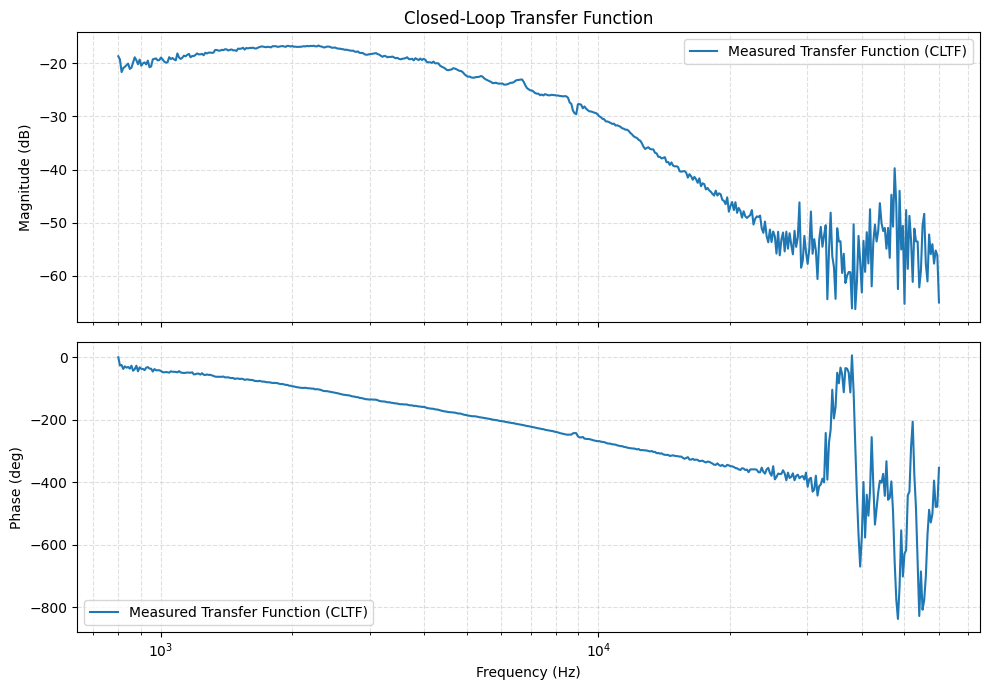

In [103]:
fig_cltf = plot_transfer_function(
    freq=freq,
    tf=cltf,
    title="Closed-Loop Transfer Function",
    label="Measured Transfer Function (CLTF)",
    color="tab:blue"
)

### Open Loop Transfer Function

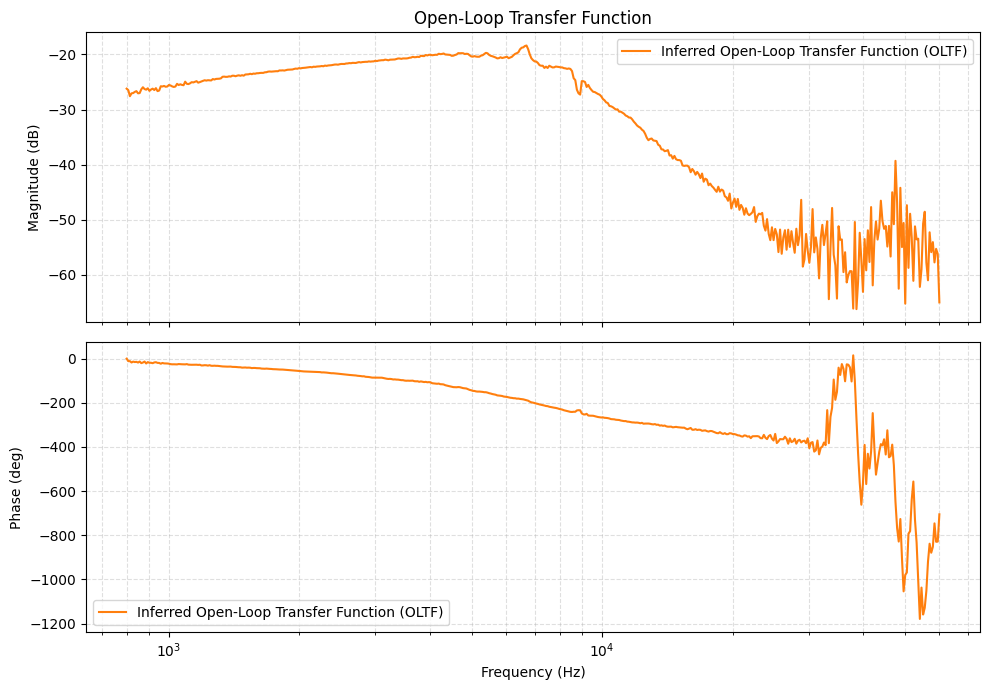

In [104]:
fig_oltf = plot_transfer_function(
    freq,
    oltf,
    "Open-Loop Transfer Function",
    "Inferred Open-Loop Transfer Function (OLTF)",
    "tab:orange"
)

<a id="save"></a>
### Step 2: Save Data

Save plots and data to csv.

In [105]:
# Base filename for this measurement

from datetime import datetime

SAVE_NAME = "EOM-00"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

FILE_PREFIX = f"{SAVE_NAME}_{timestamp}"

In [106]:
# Save figures

cltf_filename = f"{FILE_PREFIX}-cltf.png"
oltf_filename = f"{FILE_PREFIX}-oltf.png"

fig_cltf.savefig(
    cltf_filename,
    dpi=300,
    bbox_inches="tight"
)

fig_oltf.savefig(
    oltf_filename,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {cltf_filename}")
print(f"Saved: {oltf_filename}")

Saved: EOM-00_20260604_205722-cltf.png
Saved: EOM-00_20260604_205722-oltf.png


In [107]:
# Save data to CSV

df = pd.DataFrame({
    "frequency_Hz": freq,

    "cltf_real": np.real(cltf),
    "cltf_imag": np.imag(cltf),

    "oltf_real": np.real(oltf),
    "oltf_imag": np.imag(oltf)
})

csv_filename = f"{FILE_PREFIX}-vna_sweep.csv"

df.to_csv(csv_filename, index=False)

print(f"Saved: {csv_filename}")

Saved: EOM-00_20260604_205722-vna_sweep.csv
